In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
import keras
import matplotlib
import numpy as np

In [ ]:
tf.__version__, keras.__version__, matplotlib.__version__, np.__version__

('2.17.0', '3.4.1', '3.7.1', '1.26.4')

In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import utils as np_utils
import matplotlib.pyplot as plt

In [ ]:
#carregando o dataset

(X_treinamento, y_treinamento), (X_teste, y_teste) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#analisando o formato dos conjuntos

X_treinamento.shape, y_treinamento.shape, X_teste.shape, y_teste.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

Text(0.5, 1.0, 'Classe2')

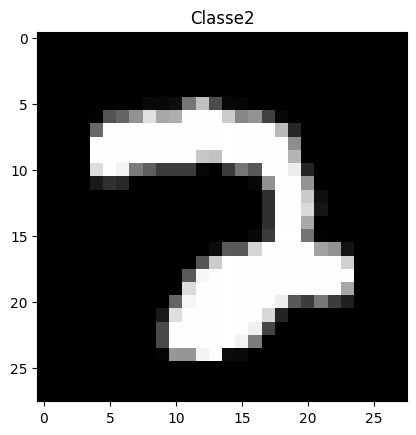

In [ ]:
#plotando uma imagem escolhida aleatóriamente

plt.imshow(X_treinamento[120], cmap='gray')
plt.title('Classe' + str(y_treinamento[120]))

In [ ]:
#redimensionando os dados para se adequarem ao formato esperado pela CNN

X_treinamento = X_treinamento.reshape(X_treinamento.shape[0], 28, 28, 1)
X_teste = X_teste.reshape(X_teste.shape[0], 28, 28, 1)
X_treinamento.shape, X_teste.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [ ]:
#normalizando os dados

X_treinamento = X_treinamento.astype('float32')
X_treinamento /= 255

X_teste = X_teste.astype('float32')
X_teste /= 255

In [ ]:
X_treinamento.max(), X_treinamento.min()

(1.0, 0.0)

In [ ]:
#convertendo para o formato one-hot encoded

y_treinamento = np_utils.to_categorical(y_treinamento, 10)
y_teste = np_utils.to_categorical(y_teste, 10)

In [ ]:
y_treinamento[120]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
#criando as camadas da rede neural
rede_neural = Sequential()

#camada de entrada
rede_neural.add(InputLayer(shape=(28, 28, 1)))

#camada de convolução
rede_neural.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
#camada de normalização
rede_neural.add(BatchNormalization())
#camada de pooling
rede_neural.add(MaxPooling2D(pool_size=(2, 2)))

#camada de convolução
rede_neural.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
#camada de normalização
rede_neural.add(BatchNormalization())
#camada de pooling
rede_neural.add(MaxPooling2D(pool_size=(2, 2)))

#camada de flattening
rede_neural.add(Flatten())
#camada oculta
rede_neural.add(Dense(units=128, activation='relu'))
#camada de dropout
rede_neural.add(Dropout(0.2))
#camada oculta
rede_neural.add(Dense(units=128, activation='relu'))
#camada de dropout
rede_neural.add(Dropout(0.2))
#camada de saída
rede_neural.add(Dense(units=10, activation='softmax'))

In [ ]:
rede_neural.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 11, 11, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 130,154 (508.41 KB)

 Trainable params: 130,026 (507.91 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
#compilando a rede neural
rede_neural.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
#realizando o treinamento
rede_neural.fit(X_treinamento, y_treinamento, batch_size=128, epochs=10, validation_data=(X_teste, y_teste))

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 130ms/step - accuracy: 0.8505 - loss: 0.4727 - val_accuracy: 0.9560 - val_loss: 0.1435
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 127ms/step - accuracy: 0.9780 - loss: 0.0745 - val_accuracy: 0.9854 - val_loss: 0.0471
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - accuracy: 0.9861 - loss: 0.0451 - val_accuracy: 0.9887 - val_loss: 0.0357
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 127ms/step - accuracy: 0.9896 - loss: 0.0356 - val_accuracy: 0.9871 - val_loss: 0.0431
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - accuracy: 0.9907 - loss: 0.0307 - val_accuracy: 0.9917 - val_loss: 0.0301
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 128ms/step - accuracy: 0.9926 - loss: 0.0240 - val_accuracy: 0.9894 - val_loss: 0.0404
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 126ms/step - accuracy: 0.9929 - loss: 0.0223 - val_accuracy: 0.9908 - val_loss: 0.0380
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 123ms/step - accuracy: 0.9928 - loss: 0

In [ ]:
resultado = rede_neural.evaluate(X_teste, y_teste)
resultado

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9904 - loss: 0.0375


[0.03336961194872856, 0.991599977016449]